# Phase 2: Building Machine Learning Models
## Decision Tree

In this notebook, we will train the Decision Tree first on our MinMax scaled data, and then completely separately on our Standard scaled data to compare the results.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

## Part 1: MinMax Scaled Dataset

### 1.1 Load the Data

In [12]:
data = pd.read_csv('Telco-Customer-Churn-MinMax.csv')
df = pd.DataFrame(data)
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,0.013889,0,1,0.11,0.003339,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,0.472222,1,0,0.38,0.217526,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,0.027778,1,1,0.35,0.012437,1,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,0.625000,0,0,0.24,0.211884,0,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,0.027778,1,1,0.52,0.017388,1,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,0.333333,1,1,0.66,0.229157,0,...,1,0,1,0,1,1,0,0,0,1
7039,0,0,1,1,1.000000,1,1,0.85,0.847766,0,...,0,0,1,0,1,1,0,1,0,0
7040,0,0,1,1,0.152778,0,1,0.11,0.039843,0,...,0,0,0,0,0,0,0,0,1,0
7041,1,1,1,0,0.055556,1,1,0.56,0.035237,1,...,0,0,0,0,0,0,0,0,0,1


### 1.2 Train-Test Split (Data Segregation)
We split the data: $80\%$ for training, $20\%$ for testing. `random_state=42` ensures reproducible results.

In [13]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Data Size:", X_train.shape) 
print("Testing Data Size:", X_test.shape)

Training Data Size: (5634, 30)
Testing Data Size: (1409, 30)


### 1.3 Train the Model

In [14]:
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

### 1.4 Evaluate the Model

Accuracy Score: 0.7253371185237757

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.83      0.82      1036
           1       0.48      0.43      0.46       373

    accuracy                           0.73      1409
   macro avg       0.64      0.63      0.64      1409
weighted avg       0.72      0.73      0.72      1409



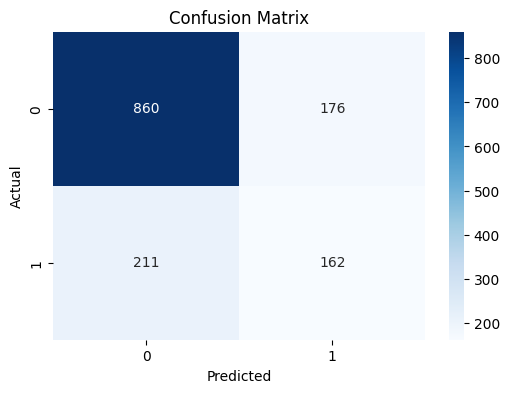

In [15]:
y_test_pred = model.predict(X_test)
print("Accuracy Score:", accuracy_score(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))

cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6,4))
sb.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## Part 2: Standard Scaled Dataset

### 2.1 Load the Data

In [16]:
data = pd.read_csv('Telco-Customer-Churn-Standard.csv')
df = pd.DataFrame(data)
df

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,1,0,-1.277445,0,1,-1.172988,-0.992780,0,...,0,0,0,0,0,0,0,0,1,0
1,1,0,0,0,0.066327,1,0,-0.275697,-0.172179,0,...,0,0,0,0,0,1,0,0,0,1
2,1,0,0,0,-1.236724,1,1,-0.375396,-0.957927,1,...,0,0,0,0,0,0,0,0,0,1
3,1,0,0,0,0.514251,0,0,-0.740959,-0.193797,0,...,1,0,0,0,0,1,0,0,0,0
4,0,0,0,0,-1.236724,1,1,0.189564,-0.938956,1,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,1,1,-0.340876,1,1,0.654826,-0.127619,0,...,1,0,1,0,1,1,0,0,0,1
7039,0,0,1,1,1.613701,1,1,1.286253,2.242419,0,...,0,0,1,0,1,1,0,1,0,0
7040,0,0,1,1,-0.870241,0,1,-1.172988,-0.852925,0,...,0,0,0,0,0,0,0,0,1,0
7041,1,1,1,0,-1.155283,1,1,0.322496,-0.870572,1,...,0,0,0,0,0,0,0,0,0,1


### 2.2 Train-Test Split (Data Segregation)

In [17]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Data Size:", X_train.shape) 
print("Testing Data Size:", X_test.shape)

Training Data Size: (5634, 30)
Testing Data Size: (1409, 30)


### 2.3 Train the Model

In [18]:
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

### 2.4 Evaluate the Model

Accuracy Score: 0.7239176721078779

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.82      0.81      1036
           1       0.48      0.45      0.46       373

    accuracy                           0.72      1409
   macro avg       0.64      0.63      0.64      1409
weighted avg       0.72      0.72      0.72      1409



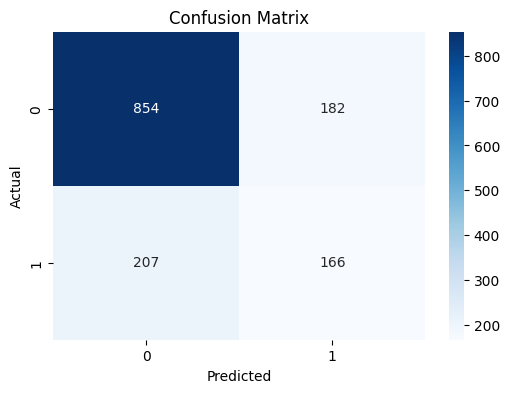

In [19]:
y_test_pred = model.predict(X_test)
print("Accuracy Score:", accuracy_score(y_test, y_test_pred))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))

cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6,4))
sb.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## Part 3: Mathematical Theory & Explanations

### 📊 Model Deep Dive: Decision Tree

**What type of graph does it make?**
*   A hierarchical **flowchart** (or an upside-down tree). It is a series of nodes consisting of "True or False" questions that split into smaller branches.

**When to use it?**
*   When there are complex, **non-linear** relationships in the data, or when you have a messy dataset that you don't necessarily want to spend hours applying Standard/MinMax scaling to (Decision Trees do not care about scale).

**Why use it?**
*   It is the most "human-readable" model in the world. You can literally print out the flowchart and show it to a business stakeholder, and they will perfectly understand the "If-Then" logic the model is using.


### Decision Tree Classifier
Decision Trees don't draw lines; they play a giant game of "20 Questions" (e.g. *Is Tenure > 12?*, *Is Contract = Month-to-Month?*), splitting the data at each step.

**How it decides where to split (Gini Impurity):**
The tree calculates the **Gini Impurity** for all possible splits and perpetually locks in the split that creates the most "pure" child nodes. 
$$Gini = 1 - \sum (p_i)^2$$
*   **$p_i$** is the probability of a randomly chosen customer belonging to class $i$ (e.g., $10$ people; $3$ churned = $p_i$ of $0.3$).
*   A Gini of **$0.0$** means the node is perfectly pure (e.g., $100\%$ Churners). The tree stops splitting.
*   A Gini of **$0.5$** means the node is perfectly mixed ($50\%$ Churners, $50\%$ Non-Churners).

*Tip: If left unrestrained (no `max_depth`), Decision Trees will memorize the training data until every leaf is $0.0$, leading to massive overfitting.*



## Part 4: The Fundamental Difference in Metrics
*   Use **Regression Metrics** (MAE, RMSE, $R^2$, Residuals) when your answer is a *continuous number* (Price: $\$250, \$599.99, \$10$). You measure the *distance* of the error.
*   Use **Classification Metrics** (Accuracy, Precision, Recall, Confusion Matrix) when your answer is a *strict category* (Churn: `Yes` or `No`). You measure the *count* of correct vs incorrect predictions. 

### Regression Metrics Explained (Predicting Continuous Numbers)
* **Mean Absolute Error (MAE):** The average absolute distance between the actual value and the predicted value. (e.g. "On average, our house price prediction was off by $\$5,000$").
* **Mean Squared Error (MSE):** The average of the *squared* distances. Squaring punishes the model heavily for making massive outliers/mistakes. 
* **Root Mean Squared Error (RMSE):** The square root of MSE. This brings the error back into the original units (e.g. "Dollars" instead of "Squared Dollars").
* **$R^2$ (R-Squared) Score:** This is the ultimate "goodness of fit" score. It tells us the percentage of the data's movement that is actually explained by our model.
  * $R^2 = 1 - \frac{Sum\ of\ Squared\ Residuals\ (SSR)}{Total\ Sum\ of\ Squares\ (SST)}$
  * **SSR (Sum of Squared Residuals):** The sum of the squared differences between the actual observed value ($y_i$) and the model's predicted value ($\hat{y}_i$). This measures the *unexplained* variance (the error of our line).
  * **SST (Total Sum of Squares):** The sum of the squared differences between the actual observed value ($y_i$) and the average/mean of all observed values ($\bar{y}$). This measures the *total variance* in the dataset (how spread out the data is from its own average).
* **Residuals:** The difference between the observed value and the predicted value. 
  $$Residual = y_i - \hat{y}_i$$

### Classification Metrics Explained (Predicting Strict Categories)
Because we are predicting strict categories (`1` or `0`), we use **Classification Metrics** to measure the *count* of correct vs. incorrect buckets.

**1. The Confusion Matrix**
The foundation of all classification metrics. It categorizes predictions into four absolute buckets:
* **True Positives (TP):** We predicted Churn ($1$), and they actually Churned ($1$).
* **True Negatives (TN):** We predicted No Churn ($0$), and they actually Didn't Churn ($0$).
* **False Positives (FP) [Type I Error]:** We predicted Churn ($1$), but they Didn't Churn ($0$). *(False Alarm)*
* **False Negatives (FN) [Type II Error]:** We predicted No Churn ($0$), but they actually Churned ($1$). *(Missed Opportunity)*

**2. Accuracy Score**
The percentage of total predictions the model got completely right.
$$Accuracy = \frac{TP + TN}{TP + TN + FP + FN}$$

**3. Precision (Quality of Positive Predictions)**
"Out of all the customers we *predicted* would churn, how many *actually* churned?"
$$Precision = \frac{TP}{TP + FP}$$

**4. Recall / Sensitivity (Quantity of Positive Predictions)**
"Out of all the customers who *actually* churned, how many did we successfully *find*?"
$$Recall = \frac{TP}{TP + FN}$$

**5. F1-Score**
The harmonic mean of Precision and Recall. It is the gold standard metric when your dataset is imbalanced.
$$F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$

### 📈 Visualization: Plotting the actual trained Decision Tree

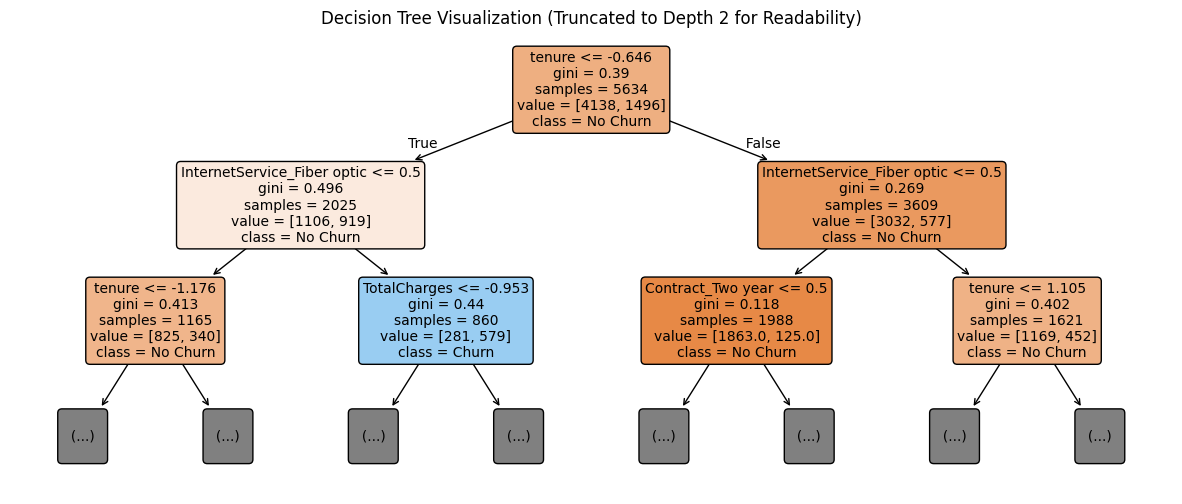

In [20]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))
# We visualize our model, limiting the depth to 2 so it is readable on screen
plot_tree(model, max_depth=2, feature_names=X.columns, class_names=['No Churn', 'Churn'], filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree Visualization (Truncated to Depth 2 for Readability)")
plt.show()